##Task1

In [1]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [2]:
#Tokenizer download
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [3]:
def preprocess(text):
  text = re.sub(r'\\',' ',text)#remove tags
  text = re.sub(r'\s+',' ',text) # remove newline and tags
  text = re.sub(r'[^\x00-\x7F]+',' ',text) #remove non-ASCII(filter English only)
  text = text.lower() # Lower-casing
  text = re.sub(r'[^a-z\s]','',text) # remove non textual content(numbers) ,keep only alphabets,letters ans space
  tokens = word_tokenize(text) #Tokenize
  return tokens

In [4]:
# Read uploaded file
with open("Corpus.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

In [ ]:
raw_text

'Welcome to the Department of Bioscience & Bioengineering\nThe Department of Bioscience & Bioengineering at IIT Jodhpur, established in 2009 offers a B.Tech. program in Bioengineering, an M.Tech. and M.Tech-Ph.D. dual degree programs in Bioscience & Bioengineering. Our programs are uniquely designed to inspire innovations in biotechnology, engineering, and medicine from an understanding of  biological systems.  This capacity building is assuming importance in the present times for providing solutions to societal problems in trans-disciplinary frameworks. A major focus is on neurosciences and neurodegenerative disorders, mechanistic biology, environmental and medical microbiology, computational biology, precision health, and bioprospecting for novel molecules and bio-actives from natural resources of the Thar ecoregion. We also offer a competitive Ph.D. program to inculcate scientific temper, independent thinking, and skillsets for scientific entrepreneurship. We encourage and provide a

In [5]:
#treating paragraphs as individual doc for the corpus
raw = raw_text.split('\n\n')
clean_corp = [preprocess(d) for d in raw if d.strip()]

In [6]:
corpus = [d for d in clean_corp if d]

In [7]:
corpus

[['welcome',
  'to',
  'the',
  'department',
  'of',
  'bioscience',
  'bioengineering',
  'the',
  'department',
  'of',
  'bioscience',
  'bioengineering',
  'at',
  'iit',
  'jodhpur',
  'established',
  'in',
  'offers',
  'a',
  'btech',
  'program',
  'in',
  'bioengineering',
  'an',
  'mtech',
  'and',
  'mtechphd',
  'dual',
  'degree',
  'programs',
  'in',
  'bioscience',
  'bioengineering',
  'our',
  'programs',
  'are',
  'uniquely',
  'designed',
  'to',
  'inspire',
  'innovations',
  'in',
  'biotechnology',
  'engineering',
  'and',
  'medicine',
  'from',
  'an',
  'understanding',
  'of',
  'biological',
  'systems',
  'this',
  'capacity',
  'building',
  'is',
  'assuming',
  'importance',
  'in',
  'the',
  'present',
  'times',
  'for',
  'providing',
  'solutions',
  'to',
  'societal',
  'problems',
  'in',
  'transdisciplinary',
  'frameworks',
  'a',
  'major',
  'focus',
  'is',
  'on',
  'neurosciences',
  'and',
  'neurodegenerative',
  'disorders',
  'm

In [8]:
total_docs = len(corpus)
tokens = [t for d in corpus for t in d]
total_tokens = len(tokens)
vocab_size = len(set(tokens))

In [9]:
print('Dataset Statistics')
print(f"Total Documents : {total_docs}")
print(f"Total Tokens : {total_tokens}")
print(f"Vocabulary Size : {vocab_size}")

Dataset Statistics
Total Documents : 442
Total Tokens : 20268
Vocabulary Size : 2846


In [11]:
#Save cleaned corpus
with open("Cleaned_corpus.txt","w",encoding="utf-8") as f:
    for line in corpus:
        f.write(" ".join(line)+"\n")
print("Cleaned data saved to 'Cleaned_corpus.txt")

Cleaned data saved to 'Cleaned_corpus.txt


Word Cloud

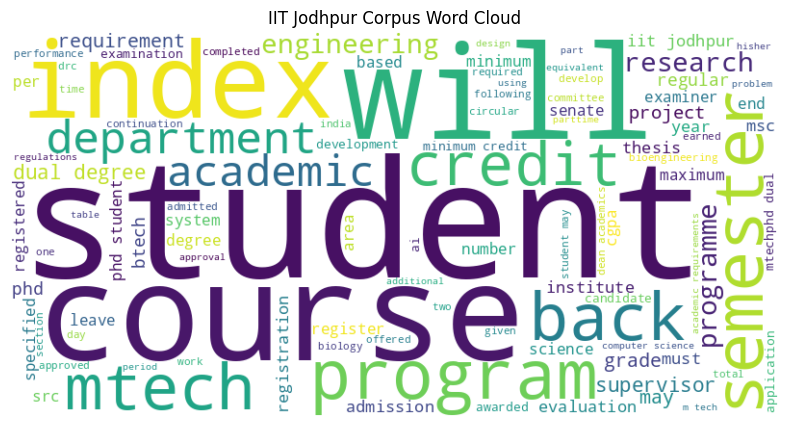

In [12]:
full_text_string = " ".join(tokens)
wordcloud = WordCloud(width=800, height=400, background_color='white',
                      colormap='viridis', max_words=100).generate(full_text_string)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("IIT Jodhpur Corpus Word Cloud")
plt.show()

##Task 2

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import Counter
import numpy as np

In [14]:
!pip install gensim
from gensim.models import Word2Vec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 47.6 MB/s eta 0:00:00


In [15]:
# Vocabulary set up
def load_corpus(path,mf = 2):
  with open(path,'r',encoding='utf-8') as f:
    tokens = f.read().split() # Reads file and splits into a list of all words
  #Count frequencies and filter rare words
  rc = Counter(tokens)
  fil_tokens = [w for w in tokens if rc[w] > mf]
  return fil_tokens

In [22]:
path = "/content/Cleaned_corpus.txt"
corpus = load_corpus(path,mf=2)

In [23]:
corpus

['to',
 'the',
 'department',
 'of',
 'bioscience',
 'bioengineering',
 'the',
 'department',
 'of',
 'bioscience',
 'bioengineering',
 'at',
 'iit',
 'jodhpur',
 'in',
 'offers',
 'a',
 'btech',
 'program',
 'in',
 'bioengineering',
 'an',
 'mtech',
 'and',
 'mtechphd',
 'dual',
 'degree',
 'programs',
 'in',
 'bioscience',
 'bioengineering',
 'our',
 'programs',
 'are',
 'designed',
 'to',
 'in',
 'biotechnology',
 'engineering',
 'and',
 'medicine',
 'from',
 'an',
 'understanding',
 'of',
 'biological',
 'systems',
 'this',
 'building',
 'is',
 'in',
 'the',
 'present',
 'for',
 'providing',
 'solutions',
 'to',
 'societal',
 'problems',
 'in',
 'transdisciplinary',
 'a',
 'major',
 'focus',
 'is',
 'on',
 'and',
 'biology',
 'environmental',
 'and',
 'medical',
 'microbiology',
 'computational',
 'biology',
 'precision',
 'health',
 'and',
 'for',
 'novel',
 'and',
 'from',
 'natural',
 'of',
 'the',
 'we',
 'also',
 'offer',
 'a',
 'phd',
 'program',
 'to',
 'inculcate',
 'scient

In [18]:
#Vocabulary
vocab = list(set(corpus))
# paddinfg token for CBow
vocab.append("<PAD>")

word_to_idx = {w:i for i,w in enumerate(vocab)}
idx_to_word = {i:w for i,w in enumerate(vocab)}

vocab_size = len(vocab)
pad_idx = word_to_idx["<PAD>"]

print(f"Corpus size: {len(corpus)} words")
print(f"Vocabulary size: {vocab_size}")

Corpus size: 17953 words
Vocabulary size: 1021


In [25]:
# Word frequencies excluding <PAD>
word_count = Counter(corpus)
total_words = sum(word_count.values())

#Uniform distribution
uni_dist = np.zeros(vocab_size)
for i in range(vocab_size):
  if idx_to_word[i] != "<PAD>":
    uni_dist[i] = word_count[idx_to_word[i]]/total_words
# P(w) = U(w)^(3/4) / Z
power = 0.75
neg_sample_dist = np.power(uni_dist,power)
neg_sample_dist = neg_sample_dist/np.sum(neg_sample_dist)

#Convert to pytorch tensor
neg_sample_dist_tensor = torch.FloatTensor(neg_sample_dist)

def get_negative_samples(batch_size,num_samples):
  return torch.multinomial(neg_sample_dist_tensor, batch_size * num_samples, replacement=True).view(batch_size, num_samples) # Draws samples based on 3/4 power distribution

def generate_training_data(corpus,window_size,model = "skipgram"):
  data = []
  idx = [word_to_idx[w] for w in corpus]
  for i,center_word in enumerate(idx):
    context_st = max(0,i-window_size)
    context_end = min(len(idx),i+window_size+1)
    context_word = [idx[j] for j in range(context_st,context_end) if j!=i]
    if model == "skipgram":
      for c in context_word:
        data.append((center_word,c))
    elif model == "cbow":
      if len(context_word) < 2*window_size:
        padding = [pad_idx] * (2*window_size-len(context_word))
        context_word.extend(padding)
      data.append((context_word,center_word))

  return data



In [26]:
#Skip-gram
class SkipGramNegSampling(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(SkipGramNegSampling, self).__init__()
        self.center_embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.outside_embeddings = nn.Embedding(vocab_size, embedding_dim)
        nn.init.uniform_(self.center_embeddings.weight, -0.5/embedding_dim, 0.5/embedding_dim)
        nn.init.zeros_(self.outside_embeddings.weight)

    def forward(self, center_words, context_words, negative_words):
        v_c = self.center_embeddings(center_words)
        u_o = self.outside_embeddings(context_words)
        u_k = self.outside_embeddings(negative_words)

        pos_score = torch.bmm(u_o.unsqueeze(1), v_c.unsqueeze(2)).squeeze()
        neg_score = torch.bmm(u_k, v_c.unsqueeze(2)).squeeze(-1)
        return pos_score, neg_score

In [27]:
#CBow
class CBOWNegSampling(nn.Module):
    def __init__(self, vocab_size, embedding_dim, pad_idx):
        super(CBOWNegSampling, self).__init__()
        # Use padding_idx so the PAD token doesn't affect gradients
        self.context_embeddings = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.target_embeddings = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)

    def forward(self, context_words, center_words, negative_words):
        v_c = self.context_embeddings(context_words).mean(dim=1)
        u_o = self.target_embeddings(center_words)
        u_k = self.target_embeddings(negative_words)

        pos_score = torch.bmm(u_o.unsqueeze(1), v_c.unsqueeze(2)).squeeze()
        neg_score = torch.bmm(u_k, v_c.unsqueeze(2)).squeeze(-1)
        return pos_score, neg_score

In [28]:
#Objective function
def negative_sampling_loss(pos_score, neg_score):
    pos_loss = -F.logsigmoid(pos_score)
    neg_loss = -torch.sum(F.logsigmoid(-neg_score), dim=1)
    return torch.mean(pos_loss + neg_loss)

In [29]:
#Training Loop
def train_word2vec(model_type="skipgram", embed_dim=50, window_size=3, num_neg_samples=5, epochs=3, batch_size=256):
    print(f"\nTraining {model_type.upper()} | Dim: {embed_dim} | Window: {window_size} | NegSamples: {num_neg_samples}")

    data = generate_training_data(corpus, window_size, model_type)

    if model_type == "skipgram":
        model = SkipGramNegSampling(vocab_size, embed_dim)
    else:
        model = CBOWNegSampling(vocab_size, embed_dim, pad_idx)

    # FIXED: Standard Adam Optimizer to prevent crashes
    optimizer = optim.Adam(model.parameters(), lr=0.01)



    for epoch in range(epochs):
        total_loss = 0
        np.random.shuffle(data)

        for i in range(0, len(data), batch_size):
            batch = data[i:i+batch_size]

            if model_type == "skipgram":
                centers = torch.tensor([b[0] for b in batch], dtype=torch.long)
                contexts = torch.tensor([b[1] for b in batch], dtype=torch.long)
                neg_samples = get_negative_samples(len(batch), num_neg_samples)

                optimizer.zero_grad()
                pos_score, neg_score = model(centers, contexts, neg_samples)

            else: # CBOW
                contexts = torch.tensor([b[0] for b in batch], dtype=torch.long)
                centers = torch.tensor([b[1] for b in batch], dtype=torch.long)
                neg_samples = get_negative_samples(len(batch), num_neg_samples)

                optimizer.zero_grad()
                pos_score, neg_score = model(contexts, centers, neg_samples)

            loss = negative_sampling_loss(pos_score, neg_score)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"  Epoch {epoch+1}/{epochs}, Loss: {total_loss/(len(data)/batch_size):.4f}")

    return model

Skipgram

In [ ]:
model_sk1 = train_word2vec("skipgram",embed_dim=50,window_size=3,num_neg_samples=5,epochs=10,batch_size=128)


Training SKIPGRAM | Dim: 50 | Window: 3 | NegSamples: 5
  Epoch 1/10, Loss: 2.5761
  Epoch 2/10, Loss: 2.2297
  Epoch 3/10, Loss: 2.1179
  Epoch 4/10, Loss: 2.0605
  Epoch 5/10, Loss: 2.0287
  Epoch 6/10, Loss: 2.0082
  Epoch 7/10, Loss: 1.9957
  Epoch 8/10, Loss: 1.9869
  Epoch 9/10, Loss: 1.9821
  Epoch 10/10, Loss: 1.9802


In [ ]:
model_sk2 = train_word2vec("skipgram",embed_dim=80,window_size=2,num_neg_samples=5,epochs=10,batch_size=128)


Training SKIPGRAM | Dim: 80 | Window: 2 | NegSamples: 5
  Epoch 1/10, Loss: 2.5871
  Epoch 2/10, Loss: 2.1446
  Epoch 3/10, Loss: 1.9769
  Epoch 4/10, Loss: 1.8892
  Epoch 5/10, Loss: 1.8439
  Epoch 6/10, Loss: 1.8189
  Epoch 7/10, Loss: 1.7957
  Epoch 8/10, Loss: 1.7937
  Epoch 9/10, Loss: 1.7868
  Epoch 10/10, Loss: 1.7770


In [ ]:
model_sk3 = train_word2vec("skipgram",embed_dim=100,window_size=2,num_neg_samples=5,epochs=10,batch_size=128)


Training SKIPGRAM | Dim: 100 | Window: 2 | NegSamples: 5
  Epoch 1/10, Loss: 2.5732
  Epoch 2/10, Loss: 2.1364
  Epoch 3/10, Loss: 1.9610
  Epoch 4/10, Loss: 1.8875
  Epoch 5/10, Loss: 1.8442
  Epoch 6/10, Loss: 1.8340
  Epoch 7/10, Loss: 1.8210
  Epoch 8/10, Loss: 1.8186
  Epoch 9/10, Loss: 1.8125
  Epoch 10/10, Loss: 1.8040


In [ ]:
model_sk4 = train_word2vec("skipgram",embed_dim=150,window_size=3,num_neg_samples=10,epochs=10,batch_size=128)


Training SKIPGRAM | Dim: 150 | Window: 3 | NegSamples: 10
  Epoch 1/10, Loss: 3.2646
  Epoch 2/10, Loss: 2.8742
  Epoch 3/10, Loss: 2.7472
  Epoch 4/10, Loss: 2.6941
  Epoch 5/10, Loss: 2.6711
  Epoch 6/10, Loss: 2.6693
  Epoch 7/10, Loss: 2.6504
  Epoch 8/10, Loss: 2.6491
  Epoch 9/10, Loss: 2.6495
  Epoch 10/10, Loss: 2.6372


In [ ]:
model_sk5 = train_word2vec("skipgram",embed_dim=80,window_size=1,num_neg_samples=5,epochs=10,batch_size=256)


Training SKIPGRAM | Dim: 80 | Window: 1 | NegSamples: 5
  Epoch 1/10, Loss: 2.8217
  Epoch 2/10, Loss: 2.1258
  Epoch 3/10, Loss: 1.8161
  Epoch 4/10, Loss: 1.6373
  Epoch 5/10, Loss: 1.5212
  Epoch 6/10, Loss: 1.4504
  Epoch 7/10, Loss: 1.4090
  Epoch 8/10, Loss: 1.3824
  Epoch 9/10, Loss: 1.3672
  Epoch 10/10, Loss: 1.3577


In [ ]:
model_sk6 = train_word2vec("skipgram",embed_dim=30,window_size=2,num_neg_samples=10,epochs=50,batch_size=256)


Training SKIPGRAM | Dim: 30 | Window: 2 | NegSamples: 10
  Epoch 1/50, Loss: 3.7235
  Epoch 2/50, Loss: 3.0544
  Epoch 3/50, Loss: 2.7969
  Epoch 4/50, Loss: 2.6396
  Epoch 5/50, Loss: 2.5442
  Epoch 6/50, Loss: 2.4840
  Epoch 7/50, Loss: 2.4488
  Epoch 8/50, Loss: 2.4242
  Epoch 9/50, Loss: 2.4012
  Epoch 10/50, Loss: 2.3851
  Epoch 11/50, Loss: 2.3735
  Epoch 12/50, Loss: 2.3650
  Epoch 13/50, Loss: 2.3569
  Epoch 14/50, Loss: 2.3490
  Epoch 15/50, Loss: 2.3460
  Epoch 16/50, Loss: 2.3426
  Epoch 17/50, Loss: 2.3361
  Epoch 18/50, Loss: 2.3289
  Epoch 19/50, Loss: 2.3266
  Epoch 20/50, Loss: 2.3231
  Epoch 21/50, Loss: 2.3216
  Epoch 22/50, Loss: 2.3205
  Epoch 23/50, Loss: 2.3139
  Epoch 24/50, Loss: 2.3159
  Epoch 25/50, Loss: 2.3128
  Epoch 26/50, Loss: 2.3141
  Epoch 27/50, Loss: 2.3086
  Epoch 28/50, Loss: 2.3082
  Epoch 29/50, Loss: 2.3076
  Epoch 30/50, Loss: 2.3079
  Epoch 31/50, Loss: 2.3054
  Epoch 32/50, Loss: 2.3028
  Epoch 33/50, Loss: 2.2997
  Epoch 34/50, Loss: 2.3019

In [ ]:
model_sk7 = train_word2vec("skipgram",embed_dim=50,window_size=2,num_neg_samples=15,epochs=50,batch_size=128)


Training SKIPGRAM | Dim: 50 | Window: 2 | NegSamples: 15
  Epoch 1/50, Loss: 4.0042
  Epoch 2/50, Loss: 3.2387
  Epoch 3/50, Loss: 2.9970
  Epoch 4/50, Loss: 2.8613
  Epoch 5/50, Loss: 2.7796
  Epoch 6/50, Loss: 2.7264
  Epoch 7/50, Loss: 2.6951
  Epoch 8/50, Loss: 2.6707
  Epoch 9/50, Loss: 2.6610
  Epoch 10/50, Loss: 2.6461
  Epoch 11/50, Loss: 2.6389
  Epoch 12/50, Loss: 2.6354
  Epoch 13/50, Loss: 2.6306
  Epoch 14/50, Loss: 2.6225
  Epoch 15/50, Loss: 2.6210
  Epoch 16/50, Loss: 2.6207
  Epoch 17/50, Loss: 2.6208
  Epoch 18/50, Loss: 2.6149
  Epoch 19/50, Loss: 2.6118
  Epoch 20/50, Loss: 2.6152
  Epoch 21/50, Loss: 2.6086
  Epoch 22/50, Loss: 2.6122
  Epoch 23/50, Loss: 2.6173
  Epoch 24/50, Loss: 2.6077
  Epoch 25/50, Loss: 2.6095
  Epoch 26/50, Loss: 2.6019
  Epoch 27/50, Loss: 2.6025
  Epoch 28/50, Loss: 2.6021
  Epoch 29/50, Loss: 2.6011
  Epoch 30/50, Loss: 2.6051
  Epoch 31/50, Loss: 2.6070
  Epoch 32/50, Loss: 2.6033
  Epoch 33/50, Loss: 2.6064
  Epoch 34/50, Loss: 2.5976

In [ ]:
Cbow_model1= train_word2vec("cbow",embed_dim=50,window_size=2,num_neg_samples=5,epochs=30,batch_size=128)


Training CBOW | Dim: 50 | Window: 2 | NegSamples: 5
  Epoch 1/30, Loss: 7.3145
  Epoch 2/30, Loss: 4.1753
  Epoch 3/30, Loss: 2.9023
  Epoch 4/30, Loss: 2.3266
  Epoch 5/30, Loss: 1.9694
  Epoch 6/30, Loss: 1.7180
  Epoch 7/30, Loss: 1.5325
  Epoch 8/30, Loss: 1.3878
  Epoch 9/30, Loss: 1.2726
  Epoch 10/30, Loss: 1.1804
  Epoch 11/30, Loss: 1.0923
  Epoch 12/30, Loss: 1.0324
  Epoch 13/30, Loss: 0.9749
  Epoch 14/30, Loss: 0.9369
  Epoch 15/30, Loss: 0.8971
  Epoch 16/30, Loss: 0.8586
  Epoch 17/30, Loss: 0.8181
  Epoch 18/30, Loss: 0.8008
  Epoch 19/30, Loss: 0.7796
  Epoch 20/30, Loss: 0.7562
  Epoch 21/30, Loss: 0.7337
  Epoch 22/30, Loss: 0.7129
  Epoch 23/30, Loss: 0.7028
  Epoch 24/30, Loss: 0.6781
  Epoch 25/30, Loss: 0.6750
  Epoch 26/30, Loss: 0.6558
  Epoch 27/30, Loss: 0.6589
  Epoch 28/30, Loss: 0.6393
  Epoch 29/30, Loss: 0.6236
  Epoch 30/30, Loss: 0.6181


In [ ]:
Cbow_model2= train_word2vec("cbow",embed_dim=20,window_size=2,num_neg_samples=5,epochs=30,batch_size=128)


Training CBOW | Dim: 20 | Window: 2 | NegSamples: 5
  Epoch 1/30, Loss: 5.5380
  Epoch 2/30, Loss: 3.5905
  Epoch 3/30, Loss: 2.7672
  Epoch 4/30, Loss: 2.4330
  Epoch 5/30, Loss: 2.2049
  Epoch 6/30, Loss: 2.0349
  Epoch 7/30, Loss: 1.8994
  Epoch 8/30, Loss: 1.7827
  Epoch 9/30, Loss: 1.6848
  Epoch 10/30, Loss: 1.6007
  Epoch 11/30, Loss: 1.5248
  Epoch 12/30, Loss: 1.4746
  Epoch 13/30, Loss: 1.4087
  Epoch 14/30, Loss: 1.3668
  Epoch 15/30, Loss: 1.3186
  Epoch 16/30, Loss: 1.2793
  Epoch 17/30, Loss: 1.2514
  Epoch 18/30, Loss: 1.2207
  Epoch 19/30, Loss: 1.2043
  Epoch 20/30, Loss: 1.1707
  Epoch 21/30, Loss: 1.1443
  Epoch 22/30, Loss: 1.1253
  Epoch 23/30, Loss: 1.1080
  Epoch 24/30, Loss: 1.0938
  Epoch 25/30, Loss: 1.0813
  Epoch 26/30, Loss: 1.0608
  Epoch 27/30, Loss: 1.0514
  Epoch 28/30, Loss: 1.0436
  Epoch 29/30, Loss: 1.0328
  Epoch 30/30, Loss: 1.0133


In [ ]:
Cbow_model3= train_word2vec("cbow",embed_dim=50,window_size=2,num_neg_samples=15,epochs=50,batch_size=256)


Training CBOW | Dim: 50 | Window: 2 | NegSamples: 15
  Epoch 1/50, Loss: 17.8483
  Epoch 2/50, Loss: 7.1089
  Epoch 3/50, Loss: 4.8600
  Epoch 4/50, Loss: 4.0347
  Epoch 5/50, Loss: 3.4914
  Epoch 6/50, Loss: 3.1052
  Epoch 7/50, Loss: 2.8232
  Epoch 8/50, Loss: 2.6060
  Epoch 9/50, Loss: 2.4131
  Epoch 10/50, Loss: 2.2616
  Epoch 11/50, Loss: 2.1353
  Epoch 12/50, Loss: 2.0232
  Epoch 13/50, Loss: 1.9219
  Epoch 14/50, Loss: 1.8326
  Epoch 15/50, Loss: 1.7621
  Epoch 16/50, Loss: 1.6908
  Epoch 17/50, Loss: 1.6338
  Epoch 18/50, Loss: 1.5682
  Epoch 19/50, Loss: 1.5164
  Epoch 20/50, Loss: 1.4745
  Epoch 21/50, Loss: 1.4325
  Epoch 22/50, Loss: 1.3993
  Epoch 23/50, Loss: 1.3718
  Epoch 24/50, Loss: 1.3346
  Epoch 25/50, Loss: 1.3074
  Epoch 26/50, Loss: 1.2779
  Epoch 27/50, Loss: 1.2665
  Epoch 28/50, Loss: 1.2265
  Epoch 29/50, Loss: 1.1958
  Epoch 30/50, Loss: 1.1911
  Epoch 31/50, Loss: 1.1645
  Epoch 32/50, Loss: 1.1475
  Epoch 33/50, Loss: 1.1399
  Epoch 34/50, Loss: 1.1146
  

In [ ]:
# Gensim Baseline Model
gen_corpus = [corpus]
gensim_cbow = Word2Vec(sentences=gen_corpus, vector_size=50, window=2, negative=5, sg=0, min_count=2, epochs=50)

In [ ]:
gensim_sg = Word2Vec(sentences=gen_corpus, vector_size=50, window=2, negative=5, sg=1, min_count=2, epochs=30)

##Task 3

In [32]:
#Extract weights and normalize for them for cosine similarity
def norm_embed(model,model_type = "skipgram"):
  if model_type == "skipgram":
    embeddings = model.center_embeddings.weight.data.cpu() # Since center word embeddings are primary representation fro skipgrams
  else:
    embeddings = model.target_embeddings.weight.data.cpu() # for cbow target embeddings
  embeddings = F.normalize(embeddings, p=2, dim=1) #Normalize
  return embeddings


In [38]:
model_sk = train_word2vec("skipgram",embed_dim=50,window_size=2,num_neg_samples=5,epochs=50,batch_size=128)


Training SKIPGRAM | Dim: 50 | Window: 2 | NegSamples: 5
  Epoch 1/50, Loss: 2.6232
  Epoch 2/50, Loss: 2.1776
  Epoch 3/50, Loss: 2.0082
  Epoch 4/50, Loss: 1.9156
  Epoch 5/50, Loss: 1.8645
  Epoch 6/50, Loss: 1.8389
  Epoch 7/50, Loss: 1.8141
  Epoch 8/50, Loss: 1.7993
  Epoch 9/50, Loss: 1.7831
  Epoch 10/50, Loss: 1.7809
  Epoch 11/50, Loss: 1.7729
  Epoch 12/50, Loss: 1.7675
  Epoch 13/50, Loss: 1.7668
  Epoch 14/50, Loss: 1.7610
  Epoch 15/50, Loss: 1.7620
  Epoch 16/50, Loss: 1.7545
  Epoch 17/50, Loss: 1.7513
  Epoch 18/50, Loss: 1.7546
  Epoch 19/50, Loss: 1.7468
  Epoch 20/50, Loss: 1.7482
  Epoch 21/50, Loss: 1.7478
  Epoch 22/50, Loss: 1.7477
  Epoch 23/50, Loss: 1.7501
  Epoch 24/50, Loss: 1.7526
  Epoch 25/50, Loss: 1.7423
  Epoch 26/50, Loss: 1.7485
  Epoch 27/50, Loss: 1.7418
  Epoch 28/50, Loss: 1.7480
  Epoch 29/50, Loss: 1.7435
  Epoch 30/50, Loss: 1.7428
  Epoch 31/50, Loss: 1.7416
  Epoch 32/50, Loss: 1.7366
  Epoch 33/50, Loss: 1.7393
  Epoch 34/50, Loss: 1.7387


In [39]:
model_cbow = train_word2vec("cbow",embed_dim=50,window_size=2,num_neg_samples=5,epochs=50,batch_size=128)


Training CBOW | Dim: 50 | Window: 2 | NegSamples: 5
  Epoch 1/50, Loss: 7.2150
  Epoch 2/50, Loss: 4.0947
  Epoch 3/50, Loss: 2.8819
  Epoch 4/50, Loss: 2.3238
  Epoch 5/50, Loss: 1.9620
  Epoch 6/50, Loss: 1.7414
  Epoch 7/50, Loss: 1.5363
  Epoch 8/50, Loss: 1.3998
  Epoch 9/50, Loss: 1.2789
  Epoch 10/50, Loss: 1.1839
  Epoch 11/50, Loss: 1.1042
  Epoch 12/50, Loss: 1.0469
  Epoch 13/50, Loss: 0.9915
  Epoch 14/50, Loss: 0.9384
  Epoch 15/50, Loss: 0.9043
  Epoch 16/50, Loss: 0.8606
  Epoch 17/50, Loss: 0.8380
  Epoch 18/50, Loss: 0.8057
  Epoch 19/50, Loss: 0.7745
  Epoch 20/50, Loss: 0.7535
  Epoch 21/50, Loss: 0.7407
  Epoch 22/50, Loss: 0.7155
  Epoch 23/50, Loss: 0.7018
  Epoch 24/50, Loss: 0.6797
  Epoch 25/50, Loss: 0.6866
  Epoch 26/50, Loss: 0.6655
  Epoch 27/50, Loss: 0.6428
  Epoch 28/50, Loss: 0.6465
  Epoch 29/50, Loss: 0.6190
  Epoch 30/50, Loss: 0.6158
  Epoch 31/50, Loss: 0.6231
  Epoch 32/50, Loss: 0.6055
  Epoch 33/50, Loss: 0.6034
  Epoch 34/50, Loss: 0.5984
  Ep

In [40]:
sg_embeddings = norm_embed(model_sk,"skipgram")
cbow_embeddings = norm_embed(model_cbow,"cbow")

In [41]:
from gensim import topic_coherence
#Cosine Similarity(Nearest Neighbours)
def get_topn_neigh(word,embeddings,word_to_idx,idx_to_word,n=5):
  if word not in word_to_idx:
    return f"Word '{word}' not in vocabulary"
  word_idx = word_to_idx[word]
  word_vec = embeddings[word_idx]

  #Calculate cosine similarity
  s = torch.matmul(embeddings,word_vec)

  #get top N+1 indices
  top_indices = torch.topk(s,n+1).indices.tolist()

  nbd = []
  for i in top_indices :
    #Exclude word itself and padding
    if i!= word_idx and idx_to_word[i] != "<PAD>":
      nbd.append((idx_to_word[i],round(s[i].item(),4)))
      if len(nbd) == n:
        break
  return nbd


Instead of exam ,I have taken the word examination as it is present in my vocab and exam is not there in my vocab.

In [48]:
target = ['research','student','phd','examination']
print("Top 5 nearest neighbour:\n")
for word in target:
  print(f"\nTarget Word : '{word}'")
  print("Skip-gram: ",get_topn_neigh(word,sg_embeddings,word_to_idx,idx_to_word))
  print("CBOW: ",get_topn_neigh(word,cbow_embeddings,word_to_idx,idx_to_word))

Top 5 nearest neighbour:


Target Word : 'research'
Skip-gram:  [('highquality', 0.586), ('proposal', 0.5533), ('biomedical', 0.5423), ('ongoing', 0.5348), ('communicate', 0.4888)]
CBOW:  [('innovation', 0.5151), ('meeting', 0.5054), ('composition', 0.4844), ('grading', 0.4798), ('identification', 0.4687)]

Target Word : 'student'
Skip-gram:  [('terminated', 0.5125), ('attend', 0.5051), ('alive', 0.4915), ('obtain', 0.4849), ('meeting', 0.4763)]
CBOW:  [('candidate', 0.4898), ('reported', 0.4474), ('obtain', 0.4371), ('heshe', 0.4196), ('up', 0.4141)]

Target Word : 'phd'
Skip-gram:  [('parttimeexternal', 0.5771), ('status', 0.5231), ('mtech', 0.5134), ('degrees', 0.4843), ('till', 0.484)]
CBOW:  [('switch', 0.5055), ('dualdegree', 0.4937), ('enrolled', 0.4743), ('publications', 0.4683), ('nondegree', 0.4645)]

Target Word : 'examination'
Skip-gram:  [('paper', 0.5937), ('hospital', 0.5422), ('examinations', 0.5348), ('appoint', 0.525), ('comprehensive', 0.5214)]
CBOW:  [('submission',

In [43]:
#Analogy experiment
def solve_analogy(a,b,c,embeddings,word_to_idx,idx_to_word):
  for w in [a,b,c]:
    if w not in word_to_idx:
      return f"[Word '{w}' not in vocabulary]"

  vec_a = embeddings[word_to_idx[a]]
  vec_b = embeddings[word_to_idx[b]]
  vec_c = embeddings[word_to_idx[b]]

  #Apply analogy
  target_vec= vec_b-vec_a+vec_c
  target_vec = F.normalize(target_vec,p=2,dim=0)

  #Calculate cosine
  s = torch.matmul(embeddings,target_vec)
  top_ind = torch.topk(s,10).indices.tolist()

  for i in top_ind:
    word_guess = idx_to_word[i]
    #Excluding the input words and padding
    if word_guess not in [a,b,c,"<PAD>"]:
      score = s[i].item()
      return f"'{word_guess}' (Score :{score:.4f})"

  return "No valid analogy found"

In [47]:
analogy = [('ug','btech','pg'),('btech','student','phd'),('theory','examination','research')]
for i,j,k in analogy:
  print(f"\nAnalogy: {i}:{j}::{k}:?")
  print("Skip-gram Result:",solve_analogy(i,j,k,sg_embeddings,word_to_idx,idx_to_word))
  print("CBOW Result:",solve_analogy(i,j,k,cbow_embeddings,word_to_idx,idx_to_word))


Analogy: ug:btech::pg:?
Skip-gram Result: 'program' (Score :0.4593)
CBOW Result: 'currently' (Score :0.4364)

Analogy: btech:student::phd:?
Skip-gram Result: 'attend' (Score :0.4252)
CBOW Result: 'related' (Score :0.4230)

Analogy: theory:examination::research:?
Skip-gram Result: 'records' (Score :0.5103)
CBOW Result: 'iv' (Score :0.4977)


#Task 4

In [50]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

In [51]:
# Select words to visualize
w_to_viusal = ['research', 'student', 'phd', 'exam','btech', 'mtech', 'ug', 'pg','theory', 'thesis', 'medical', 'engineering','science', 'biology', 'course', 'faculty']

#Filter out the words which are not in vocab
valid_words = [w for w in w_to_viusal if w in word_to_idx]

# pytorch tensors are converted to numpy arr for sklearn
sg_vec = np.array([sg_embeddings[word_to_idx[w]].numpy() for w in valid_words])
cbow_vec = np.array([cbow_embeddings[word_to_idx[w]].numpy() for w in valid_words])

#PCA(dim 2)
pca = PCA(n_components=2)
sg_pca = pca.fit_transform(sg_vec)
cbow_pca = pca.fit_transform(cbow_vec)




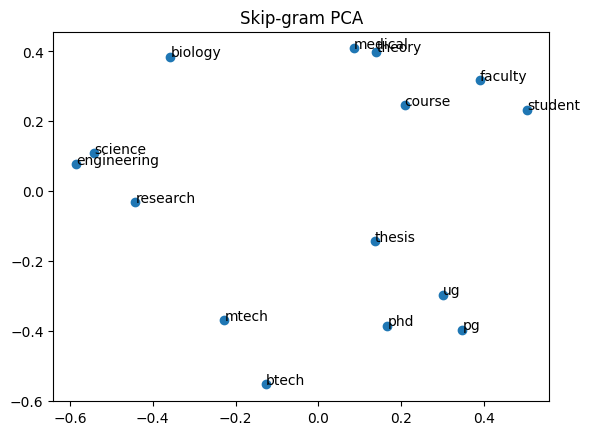

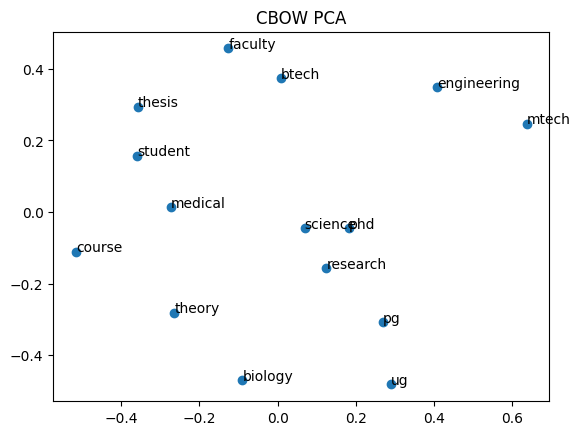

In [52]:
# Plot Skip-gram
plt.scatter(sg_pca[:, 0], sg_pca[:, 1])
for i, word in enumerate(valid_words):
    plt.text(sg_pca[i, 0], sg_pca[i, 1], word)
plt.title("Skip-gram PCA")
plt.show()

# Plot CBOW
plt.scatter(cbow_pca[:, 0], cbow_pca[:, 1])
for i, word in enumerate(valid_words):
    plt.text(cbow_pca[i, 0], cbow_pca[i, 1], word)
plt.title("CBOW PCA")
plt.show()